In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [5]:
df=pd.read_csv('/Users/keneskenesbay/Desktop/ML/data/WA_Fn-UseC_cleaned_Telco-Customer-Churn.csv')
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7005,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7006,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7007,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7008,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7010 entries, 0 to 7009
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod     7010 non-null   object 


In [7]:
df.shape

(7010, 20)

### Feature and Target Separation

We separate the input features (`X`) from the target variable (`y`).

The target variable is `Churn`, which shows whether a customer left the company.

In [10]:
X=df.drop("Churn", axis=1)
y=df["Churn"]

In [11]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7010, 19)
y shape: (7010,)


In [12]:
X.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [14]:
#Divide features into numeric and categorical
numeric_features=X.select_dtypes(include=["int64", "float64"]).columns
categorical_features=X.select_dtypes(include=["object"]).columns

print("Numeric features:", list(numeric_features))
print("Categorical features:", list(categorical_features))

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### Train-Test Split

We split the dataset into training and testing sets.

The training set is used to train the models, while the test set is used to evaluate their performance on unseen data.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5608, 19)
X_test: (1402, 19)
y_train: (5608,)
y_test: (1402,)


In [18]:
print("Train churn distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest churn distribution:")
print(y_test.value_counts(normalize=True))

Train churn distribution:
Churn
No     0.735021
Yes    0.264979
Name: proportion, dtype: float64

Test churn distribution:
Churn
No     0.735378
Yes    0.264622
Name: proportion, dtype: float64


### Data Preprocessing

Categorical features are converted into numerical values using One-Hot Encoding.

Numerical features are standardized using StandardScaler so that they have a similar scale.

In [19]:
preprocessor=ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [20]:
logistic_model =Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [21]:
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
y_pred_logistic=logistic_model.predict(X_test)

### Random Forest

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to make predictions.

In [25]:
random_forest_model=Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

In [26]:
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
y_pred_rf=random_forest_model.predict(X_test)

### Model Evaluation

We evaluate both models using accuracy, precision, recall, and F1-score.

Because the target variable is imbalanced, F1-score and recall are especially important.

In [29]:
#function for evaluating
def evaluate_model(y_true, y_pred, model_name):
    print(model_name)
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred, pos_label="Yes"), 3))
    print("Recall:", round(recall_score(y_true, y_pred, pos_label="Yes"), 3))
    print("F1-score:", round(f1_score(y_true, y_pred, pos_label="Yes"), 3))

In [30]:
evaluate_model(y_test, y_pred_logistic, "Logistic Regression")
print()
evaluate_model(y_test, y_pred_rf, "Random Forest")

Logistic Regression
Accuracy: 0.808
Precision: 0.67
Recall: 0.542
F1-score: 0.599

Random Forest
Accuracy: 0.786
Precision: 0.628
Recall: 0.469
F1-score: 0.537


### Confusion Matrix

A confusion matrix shows how many customers were correctly and incorrectly classified as churned or non-churned.

In [33]:
cm_logistic=confusion_matrix(y_test, y_pred_logistic, labels=["No", "Yes"])

print(cm_logistic)

[[932  99]
 [170 201]]


In [34]:
cm_rf=confusion_matrix(y_test, y_pred_rf, labels=["No", "Yes"])

print(cm_rf)

[[928 103]
 [197 174]]


### Confusion Matrix Visualization

The confusion matrices help visualize correct and incorrect predictions for both models.

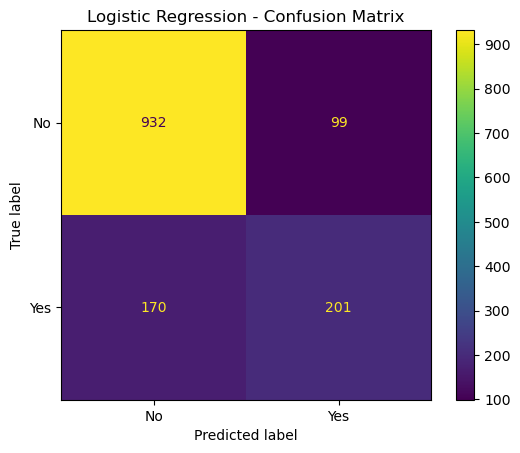

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["No", "Yes"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

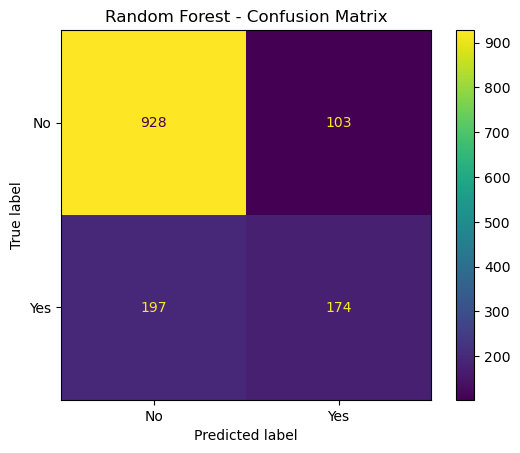

In [36]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No", "Yes"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

### Model Comparison

Logistic Regression achieved better results than Random Forest across all evaluated metrics.

It also detected more customers who actually churned, resulting in a higher recall and F1-score.

In [37]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic, pos_label="Yes"),
        precision_score(y_test, y_pred_rf, pos_label="Yes")
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic, pos_label="Yes"),
        recall_score(y_test, y_pred_rf, pos_label="Yes")
    ],
    "F1-score": [
        f1_score(y_test, y_pred_logistic, pos_label="Yes"),
        f1_score(y_test, y_pred_rf, pos_label="Yes")
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.808,0.670,0.542,0.599
1,Random Forest,0.786,0.628,0.469,0.537


In [38]:
sample=X_test.iloc[[0]]

print(sample)

     gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
743  Female              0      No         No       5          Yes   

    MultipleLines InternetService OnlineSecurity OnlineBackup  \
743            No             DSL             No           No   

    DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
743               No          No          No              No  Month-to-month   

    PaperlessBilling            PaymentMethod  MonthlyCharges  TotalCharges  
743              Yes  Credit card (automatic)           44.05        202.15  


In [39]:
prediction=logistic_model.predict(sample)

print("Predicted churn:", prediction[0])

Predicted churn: No


In [41]:
probability=logistic_model.predict_proba(sample)[0][1]

print("Probability of churn:",round(probability,3))

Probability of churn: 0.363


### Final Conclusion

Two classification models were trained to predict customer churn: Logistic Regression and Random Forest.

Logistic Regression achieved better performance on the test set:
- Accuracy: 80.8%
- Precision: 67.0%
- Recall: 54.2%
- F1-score: 59.9%

The model can be used to identify customers who are more likely to churn based on their characteristics and service information.

The project demonstrates the complete machine learning workflow, from data preprocessing to model training and evaluation.

### Classification Report

The classification report provides precision, recall, and F1-score for both churn classes.

In [43]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression
              precision    recall  f1-score   support

          No       0.85      0.90      0.87      1031
         Yes       0.67      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.80      0.81      0.80      1402



In [44]:
print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

          No       0.82      0.90      0.86      1031
         Yes       0.63      0.47      0.54       371

    accuracy                           0.79      1402
   macro avg       0.73      0.68      0.70      1402
weighted avg       0.77      0.79      0.78      1402

